In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load data 
train = pd.read_csv('../data/processed/train.csv')
test = pd.read_csv('../data/processed/test.csv')

# basic exploration for each item 
for item in ['Croissant', 'Danish']:
    data = train[train['item'] == item]['quantity']
    print(f"\n{item} Statistics:")  
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Std: {data.std():.2f}")
    print(f"  Min: {data.min():.2f}, Max: {data.max():.2f}")
    print(f"  Zeros: {(data == 0).sum()} ({(data==0).sum()/len(data)*100:.1f}%)")


Croissant Statistics:
  Mean: 54.69
  Median: 54.09
  Std: 25.14
  Min: 0.00, Max: 145.00
  Zeros: 22 (2.6%)

Danish Statistics:
  Mean: 29.91
  Median: 30.00
  Std: 15.35
  Min: 0.00, Max: 84.00
  Zeros: 25 (3.0%)


# Visualizing outliers

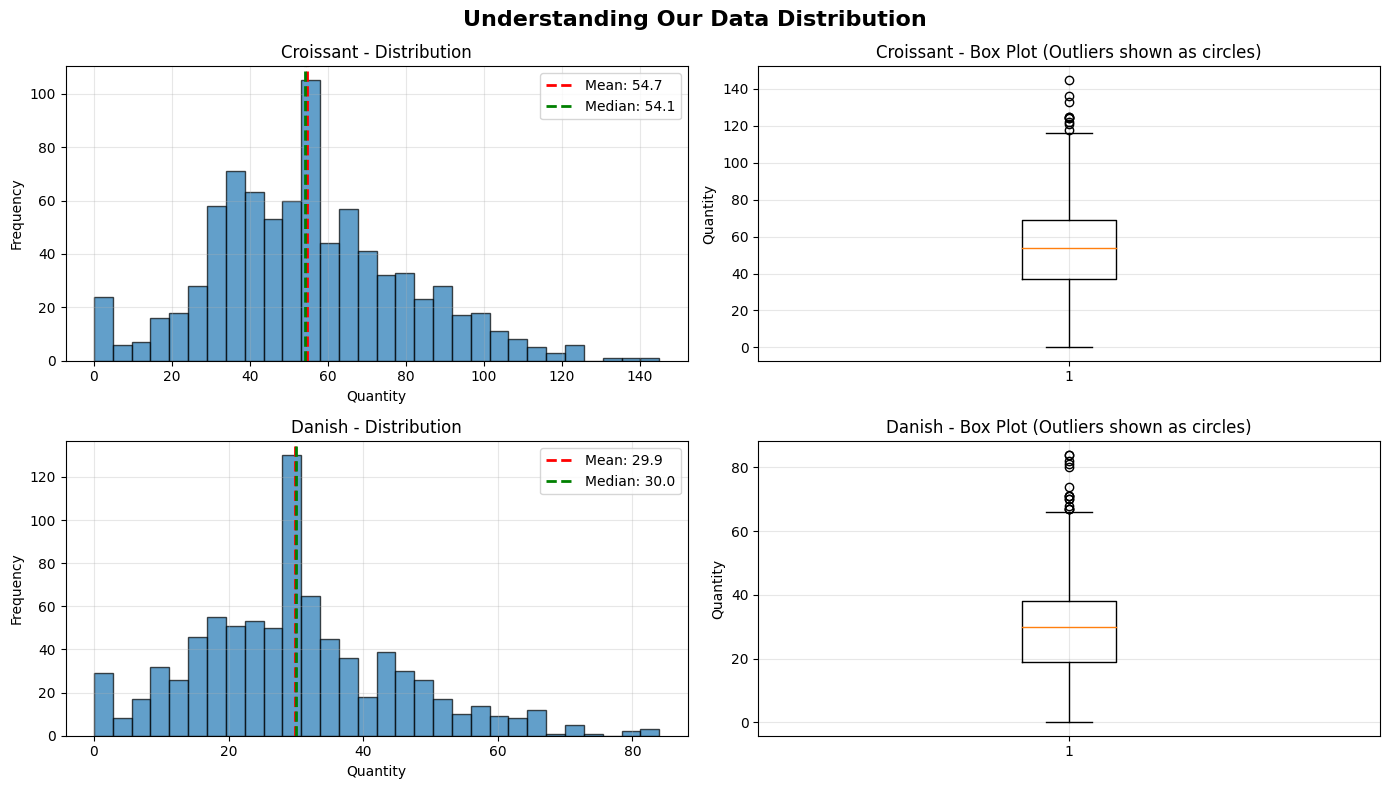

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Understanding Our Data Distribution', fontsize=16, fontweight='bold')

for idx, item in enumerate(['Croissant', 'Danish']):
    train_data = train[train['item'] == item]['quantity']
    
    # Histogram
    axes[idx, 0].hist(train_data, bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 0].axvline(train_data.mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {train_data.mean():.1f}')
    axes[idx, 0].axvline(train_data.median(), color='green', linestyle='--', 
                         linewidth=2, label=f'Median: {train_data.median():.1f}')
    axes[idx, 0].set_xlabel('Quantity')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{item} - Distribution')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)
    
    # Box plot
    axes[idx, 1].boxplot(train_data, vert=True)
    axes[idx, 1].set_ylabel('Quantity')
    axes[idx, 1].set_title(f'{item} - Box Plot (Outliers shown as circles)')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify Outliers with different methods

In [6]:
from scipy import stats

def identify_outliers(df, item_name):
    """Identify outliers using multiple methods"""
    item_data = df[df['item'] == item_name].copy()
    quantity = item_data['quantity'].values
    
    # Method 1: IQR Method
    Q1 = np.percentile(quantity, 25)
    Q3 = np.percentile(quantity, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = (quantity < lower_bound) | (quantity > upper_bound)
    
    # Method 2: Z-Score (only on non-zero values)
    non_zero_mask = quantity > 0
    z_outliers = np.zeros(len(quantity), dtype=bool)
    if non_zero_mask.sum() > 0:
        z_scores = np.abs(stats.zscore(quantity[non_zero_mask]))
        z_outliers[non_zero_mask] = z_scores > 3  # 3 std devs
    
    # Method 3: Suspicious zeros (zero but previous week had sales)
    suspicious_zeros = (quantity == 0) & (item_data['lag_1w_ago'] > 0)
    
    print(f"\n{item_name} Outlier Detection:")
    print(f"  IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  IQR outliers: {iqr_outliers.sum()} points")
    print(f"  Z-score outliers (>3 std): {z_outliers.sum()} points")
    print(f"  Suspicious zeros: {suspicious_zeros.sum()} points")
    
    # Show the actual outlier values
    iqr_outlier_values = quantity[iqr_outliers]
    if len(iqr_outlier_values) > 0:
        print(f"  IQR outlier values: {sorted(iqr_outlier_values)}")
    
    return item_data, iqr_outliers, z_outliers, suspicious_zeros

# Run for both items
croissant_data, c_iqr, c_z, c_sus = identify_outliers(train, 'Croissant')
danish_data, d_iqr, d_z, d_sus = identify_outliers(train, 'Danish')



Croissant Outlier Detection:
  IQR bounds: [-11.00, 117.00]
  IQR outliers: 10 points
  Z-score outliers (>3 std): 3 points
  Suspicious zeros: 8 points
  IQR outlier values: [118.0, 121.0, 122.0, 124.0, 124.0, 125.0, 125.0, 133.0, 136.0, 145.0]

Danish Outlier Detection:
  IQR bounds: [-9.50, 66.50]
  IQR outliers: 15 points
  Z-score outliers (>3 std): 5 points
  Suspicious zeros: 9 points
  IQR outlier values: [67.0, 67.0, 67.0, 68.0, 70.0, 70.0, 71.0, 71.0, 71.0, 74.0, 80.0, 81.0, 82.0, 84.0, 84.0]


# Where do outliers occur? 

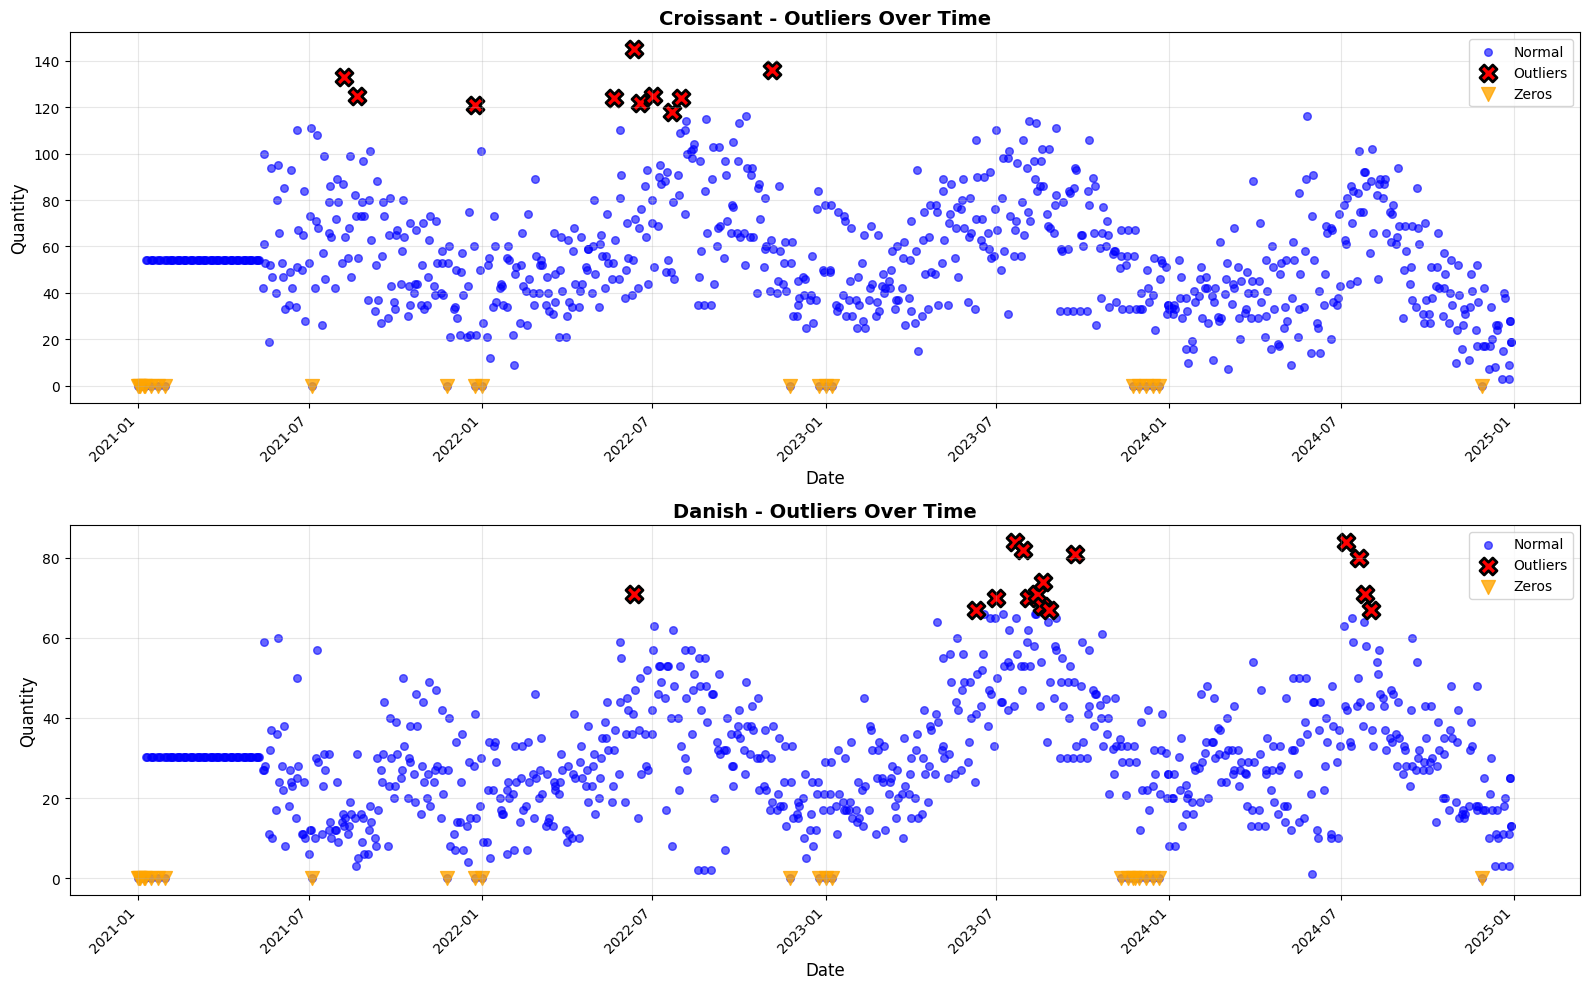

In [13]:
# Let's see outliers in time series context
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, (item, iqr_mask) in enumerate([('Croissant', c_iqr), ('Danish', d_iqr)]):
    item_data = train[train['item'] == item].copy()
    item_data['date'] = pd.to_datetime(item_data['date'])
    item_data['is_outlier'] = iqr_mask
    
    # Plot normal points
    normal = item_data[~item_data['is_outlier']]
    axes[idx].scatter(normal['date'], normal['quantity'], 
                     alpha=0.6, s=30, label='Normal', color='blue')
    
    # Plot outliers
    outliers = item_data[item_data['is_outlier']]
    axes[idx].scatter(outliers['date'], outliers['quantity'], 
                     alpha=1, s=150, label='Outliers', color='red', 
                     marker='X', edgecolors='black', linewidths=2)
    
    # Plot zeros
    zeros = item_data[item_data['quantity'] == 0]
    axes[idx].scatter(zeros['date'], zeros['quantity'], 
                     alpha=0.8, s=100, label='Zeros', color='orange', 
                     marker='v')
    
    axes[idx].set_xlabel('Date', fontsize=12)
    axes[idx].set_ylabel('Quantity', fontsize=12)
    axes[idx].set_title(f'{item} - Outliers Over Time', fontsize=14, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [8]:
# When do outliers occur?
print("\nCroissant Outliers - Day of Week:")
print(croissant_data[c_iqr]['day_of_week'].value_counts().sort_index())

print("\nDanish Outliers - Day of Week:")
print(danish_data[d_iqr]['day_of_week'].value_counts().sort_index())

print("\nAre outliers on weekends?")
print(f"Croissant: {croissant_data[c_iqr]['is_weekend'].sum()} out of {c_iqr.sum()}")
print(f"Danish: {danish_data[d_iqr]['is_weekend'].sum()} out of {d_iqr.sum()}")



Croissant Outliers - Day of Week:
day_of_week
4    2
5    7
6    1
Name: count, dtype: int64

Danish Outliers - Day of Week:
day_of_week
4     2
5    11
6     2
Name: count, dtype: int64

Are outliers on weekends?
Croissant: 8 out of 10
Danish: 13 out of 15


In [9]:
# Let's check: what % of test data would be considered "outliers" by train standards?

test_croissant = test[test['item'] == 'Croissant']['quantity']
test_danish = test[test['item'] == 'Danish']['quantity']

# Using the IQR bounds we calculated from TRAIN data
croissant_upper = 117.0  # from your output
danish_upper = 66.5      # from your output

print("Test Set Analysis:")
print(f"\nCroissant:")
print(f"  Test points above train upper bound (117): {(test_croissant > croissant_upper).sum()}")
print(f"  Percentage: {(test_croissant > croissant_upper).sum() / len(test_croissant) * 100:.1f}%")
print(f"  Test max: {test_croissant.max():.1f}")

print(f"\nDanish:")
print(f"  Test points above train upper bound (66.5): {(test_danish > danish_upper).sum()}")
print(f"  Percentage: {(test_danish > danish_upper).sum() / len(test_danish) * 100:.1f}%")
print(f"  Test max: {test_danish.max():.1f}")


Test Set Analysis:

Croissant:
  Test points above train upper bound (117): 0
  Percentage: 0.0%
  Test max: 99.0

Danish:
  Test points above train upper bound (66.5): 0
  Percentage: 0.0%
  Test max: 63.0


# Testing Train With & Without Outliers

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_evaluate(train_data, test_data, experiment_name):
    """Train model and return metrics"""
    # Prepare features (exclude date, item, quantity)
    feature_cols = ['day_of_week', 'day_of_month', 'month', 'year', 
                    'week_of_year', 'is_weekend', 'lag_1w_ago', 'lag_2w_ago', 
                    'lag_3w_ago', 'lag_4w_ago', 'rolling_mean_operational', 
                    'rolling_std_operational']
    
    X_train = train_data[feature_cols]
    y_train = train_data['quantity']
    X_test = test_data[feature_cols]
    y_test = test_data['quantity']
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{experiment_name}:")
    print(f"  Training samples: {len(train_data)}")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")
    
    return {'name': experiment_name, 'mae': mae, 'rmse': rmse, 'r2': r2, 'n_samples': len(train_data)}

# Scenario 1: Keep everything (baseline)
results = []
results.append(train_and_evaluate(train, test, "Baseline (All Data)"))

# Scenario 2: Remove extreme outliers (Z-score > 3)
# Combine the masks for both items
train_with_outlier_flags = train.copy()
train_with_outlier_flags['z_outlier'] = False
train_with_outlier_flags.loc[train['item'] == 'Croissant', 'z_outlier'] = c_z
train_with_outlier_flags.loc[train['item'] == 'Danish', 'z_outlier'] = d_z

train_no_extreme = train_with_outlier_flags[~train_with_outlier_flags['z_outlier']].drop(columns=['z_outlier'])
results.append(train_and_evaluate(train_no_extreme, test, "Remove Extreme (Z>3)"))

# Scenario 3: Remove all IQR outliers
train_with_outlier_flags['iqr_outlier'] = False
train_with_outlier_flags.loc[train['item'] == 'Croissant', 'iqr_outlier'] = c_iqr
train_with_outlier_flags.loc[train['item'] == 'Danish', 'iqr_outlier'] = d_iqr

train_no_iqr = train_with_outlier_flags[~train_with_outlier_flags['iqr_outlier']].drop(columns=['z_outlier', 'iqr_outlier'])
results.append(train_and_evaluate(train_no_iqr, test, "Remove All IQR Outliers"))

# Compare results
print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))



Baseline (All Data):
  Training samples: 1676
  MAE: 8.80
  RMSE: 11.89
  R²: 0.5945

Remove Extreme (Z>3):
  Training samples: 1668
  MAE: 8.93
  RMSE: 12.10
  R²: 0.5799

Remove All IQR Outliers:
  Training samples: 1651
  MAE: 8.90
  RMSE: 12.05
  R²: 0.5829

COMPARISON SUMMARY
                   name      mae      rmse       r2  n_samples
    Baseline (All Data) 8.799857 11.885531 0.594460       1676
   Remove Extreme (Z>3) 8.927432 12.096341 0.579947       1668
Remove All IQR Outliers 8.896655 12.054350 0.582858       1651


# Exploring R Square problem

In [11]:
# Let's see where the model is struggling
from sklearn.ensemble import RandomForestRegressor

# Retrain on full data
feature_cols = ['day_of_week', 'day_of_month', 'month', 'year', 
                'week_of_year', 'is_weekend', 'lag_1w_ago', 'lag_2w_ago', 
                'lag_3w_ago', 'lag_4w_ago', 'rolling_mean_operational', 
                'rolling_std_operational']

X_train = train[feature_cols]
y_train = train['quantity']
X_test = test[feature_cols]
y_test = test['quantity']

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Analyze errors by item
test_with_pred = test.copy()
test_with_pred['prediction'] = y_pred
test_with_pred['error'] = test_with_pred['quantity'] - y_pred
test_with_pred['abs_error'] = np.abs(test_with_pred['error'])

print("\nError Analysis by Item:")
for item in ['Croissant', 'Danish']:
    item_data = test_with_pred[test_with_pred['item'] == item]
    print(f"\n{item}:")
    print(f"  MAE: {item_data['abs_error'].mean():.2f}")
    print(f"  Mean actual: {item_data['quantity'].mean():.2f}")
    print(f"  Mean predicted: {item_data['prediction'].mean():.2f}")
    print(f"  Max error: {item_data['abs_error'].max():.2f}")
    
    # Where are the biggest errors?
    worst_10 = item_data.nlargest(10, 'abs_error')[['date', 'quantity', 'prediction', 'abs_error', 'day_of_week', 'is_weekend']]
    print(f"\n  Top 10 worst predictions:")
    print(worst_10.to_string(index=False))



Error Analysis by Item:

Croissant:
  MAE: 10.48
  Mean actual: 40.28
  Mean predicted: 41.01
  Max error: 44.96

  Top 10 worst predictions:
      date  quantity  prediction  abs_error  day_of_week  is_weekend
2025-08-08      98.0     53.0367    44.9633            4           0
2025-03-22      90.0     45.5799    44.4201            5           1
2025-10-05       9.0     48.8834    39.8834            6           1
2025-08-21      71.0     35.2400    35.7600            3           0
2025-09-04      19.0     52.5400    33.5400            3           0
2025-10-04      79.0     46.1309    32.8691            5           1
2025-06-14      85.0     52.6200    32.3800            5           1
2025-03-02      51.0     19.2133    31.7867            6           1
2025-09-11       6.0     35.9500    29.9500            3           0
2025-08-14      27.0     56.6433    29.6433            3           0

Danish:
  MAE: 7.12
  Mean actual: 25.68
  Mean predicted: 26.55
  Max error: 32.99

  Top 10 wor